# Consulta a ChatGPT usando tu mano y tu micrófono

**Al correr el código, se abrirá una la cámara y podrás cambiar distintas funciones:**

1) Cambia el valor de 'reconocer_manos' para que reconocer las manos en el video.

2) Cambia el valor de 'usar_numeros' para mostrar las 21 marcas en la mano.

3) Usa 'cambiar_color' para cambiar el color de algunas marcas de la mano. Se debe ingresar como lista con valores entre 0 a 20, por ejemplo; \[2, 5, 8, 17\]

4) Cambia 'color' para cambiar el color de las marcas señaladas. Los valores son en escala BGR (Azul, Verde, Rojo) desde 0 a 255.

5) Usa 'pregunta' para realizar una pregunta a chatGPT cuando tengas las manos cerca de la pantalla. Una vez realizada la pregunta, vuelve a alejarte.

In [5]:
# ----------------------------------------------
# Read libraries
# ----------------------------------------------
import cv2
import time
import mediapipe as mp
import numpy as np
import openai
import speech_recognition as sr
import mediapipe as mp
import pyttsx3

from ultralytics import YOLO
from ultralytics.models.yolo.detect.predict import DetectionPredictor

import Codes

# ----------------------------------------------
# Inicializadores
# ----------------------------------------------

# Configura tu clave de API de OpenAI aquí
# openai.api_key = "YOUR API KEY"
# Inicializa el reconocedor de voz
recognizer = sr.Recognizer()
# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands()
# Initialize MediaPipe Drawing
mp_drawing = mp.solutions.drawing_utils

# Inicializar el sintetizador de voz
engine = pyttsx3.init()
engine.setProperty('rate', 180)

# ----------------------------------------------
# Hand recognizer implemented with chat GPT
# ----------------------------------------------
def handTracking(show, number, changeColor, color, question):
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            continue
        # Convert the BGR image to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Process the frame to detect hands
        results = hands.process(frame_rgb)
    
        if results.multi_hand_landmarks:
            # Determinar el centro de la imagen
            center_x = frame.shape[1] // 2
            
            for i, landmarks in enumerate(results.multi_hand_landmarks):
                # Calcular la posición horizontal del centro de la mano
                x_min = min(landmark.x for landmark in landmarks.landmark)
                x_max = max(landmark.x for landmark in landmarks.landmark)
                hand_center_x = (x_min + x_max) / 2 * frame.shape[1]
                
                # Determinar la mano izquierda o derecha
                if hand_center_x < center_x:
                    hand_type = "Mano derecha"
                else:
                    hand_type = "Mano Izquierda"
                
                # Draw landmarks on the frame
                mp_drawing.draw_landmarks(frame, landmarks, mp_hands.HAND_CONNECTIONS)
    
                # Obtener las coordenadas del bounding box
                x_min = min(landmark.x for landmark in landmarks.landmark)
                y_min = min(landmark.y for landmark in landmarks.landmark)
                x_max = max(landmark.x for landmark in landmarks.landmark)
                y_max = max(landmark.y for landmark in landmarks.landmark)
                
                # Dibujar el cuadro alrededor de la mano
                cv2.rectangle(frame, (int(x_min * frame.shape[1]), int(y_min * frame.shape[0])),
                              (int(x_max * frame.shape[1]), int(y_max * frame.shape[0])),
                              (0, 255, 0), 2)
                
                # Agregar texto con el tipo de mano
                cv2.putText(frame, hand_type, (int(x_min * frame.shape[1]), int(y_min * frame.shape[0]) - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
    
                #$if question:
                #$    # Calcular el área del rectángulo que contiene la mano
                #$    area = (x_max - x_min) * (y_max - y_min) * 1000
                #$
                #$    # Si el área del rectángulo es mayor que un valor umbral, reconoce el discurso
                #$    if area > 170:  # Ajusta este valor según tu necesidad
                #$        with sr.Microphone() as source:
                #$            # Indica las instrucciones con el sintetizador de voz
                #$            engine.say('Has activado Chat GPT. Realiza una breve pregunta')
                #$            engine.runAndWait()
                #$            
                #$            # Reconocer voz a texto
                #$            recognizer.adjust_for_ambient_noise(source)
                #$            audio = recognizer.listen(source)
                #$            
                #$            # Indica instrucciones con sintetizador de voz
                #$            engine.say('Procesando tu pregunta')
                #$            engine.runAndWait()
                #$        
                #$        # Intenta entender la pregunta
                #$        try:
                #$            pregunta = recognizer.recognize_google(audio, language="es-ES")
                #$        except sr.UnknownValueError:
                #$            print("No se pudo entender el audio")
                #$        except sr.RequestError as e:
                #$            print("Error en la solicitud: {0}".format(e))
                #$        
                #$        # Si se entiende la pregunta, se ingresa como input a chatGPT
                #$        if pregunta:
                #$            respuesta = openai.Completion.create(
                #$                engine="text-davinci-002",
                #$                prompt=pregunta,
                #$                max_tokens=200  # Ajusta el número de tokens según tu preferencia
                #$            )
                #$            print("Pregunta:", pregunta)
                #$            
                #$            # Guardar respuesta
                #$            respuesta_texto = respuesta.choices[0].text
                #$            
                #$            # Usamos el sintetizador de voz para reproducir la respuesta
                #$            engine.say(respuesta_texto)
                #$            engine.runAndWait()
                #$            time.sleep(1)
                #$            
                #$            # Realiza instrucciones con el sintetizador de voz
                #$            engine.say('Gracias. Ahora puedes volver a alejar tu mano')
                #$            engine.runAndWait()
                #$            time.sleep(1)
                    
                if number == True:
                    # Add numbers to landmarks
                    for idx, landmark in enumerate(landmarks.landmark):
                        h, w, _ = frame.shape
                        cx, cy = int(landmark.x * w), int(landmark.y * h)
                        cv2.putText(frame, str(idx), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
                
                if changeColor is not None:
                    for mark in changeColor:
                        # Change the color of a specific landmark (e.g., landmark 8)
                        landmark_index_to_color = mark
                        landmark_to_change = landmarks.landmark[landmark_index_to_color]
                        cx, cy = int(landmark_to_change.x * frame.shape[1]), int(landmark_to_change.y * frame.shape[0])
                        cv2.circle(frame, (cx, cy), 5, color, -1)  # Change color to red (BGR format)
        
        # Write a instructions on screen
        #if question:
        #    cv2.putText(frame, f'Acerca tu mano para realizar una consulta a chatGPT',
        #                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 150, 255), 2)
        
        cv2.putText(frame, f'Saluda! Te estamos grabando :)',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (50, 50, 255), 3)
        
        width, height = 1600, 900
        frame = cv2.resize(frame, (width, height))
        cv2.imshow('Hand Landmarks', frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()

# ----------------------------------------------
# Use sign language recognizer from roboflow
# ----------------------------------------------
def implementation(model_directory, labels, source):
    model = YOLO(model_directory)

    model.predict(source=source, show=True)  # Generador de objetos Results
    results = model(source=source, stream=True, show = True)  # Generador de objetos Results
    
    for r in results:
        boxes = r.boxes  # Objetos Boxes para las salidas de cuadros delimitadores
        masks = r.masks  # Objetos Masks para las salidas de máscaras de segmentación
        probs = r.probs  # Probabilidades de clase para las salidas de clasificación
        
        count = 0
        if len(boxes) > 0:
            classes = int(boxes.cls[0])
            predCharacter = labels[classes]

## Usage: Hand detection

In [ ]:
# Open the webcam
cap = cv2.VideoCapture(1)

In [ ]:
show = True  # True / False
number = True  # True / False
changeColor = [8,17, 4, 16] # Lista con números del 0 al 20.
color = (250, 155, 0)  # Colores BGR (Blue, Green, Red)
question = False  # True / False

handTracking(show, number, changeColor, color, question)

## Usage: Hand Gesture

In [ ]:
model_directory = r'../datos/resultados/signLenguage_Model.pt'
# Fixed 2026-09-12 (see "Evaluacion" below): the trained model's own output index for
# classes 5-8 does NOT match the folder-collection convention (0=A...8=Y) used elsewhere
# in this notebook -- e.g. showing the model a 'Y' hand shape makes it output class 5,
# not 8. This `labels` dict is for interpreting the MODEL's raw prediction index
# (used by `implementation()` below and by the evaluation cells against `pred_cls`) --
# it is NOT the same as the folder index used when reading training images (see
# FOLDER_LABELS in the evaluation section). Was {5:'Rock',6:'U',7:'V',8:'Y'}.
labels = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F', 5: 'Y', 6: 'Rock', 7: 'U', 8: 'V'}
source = '0'
implementation(model_directory, labels, source)

## Usage: Body detection

In [ ]:
import cv2
import mediapipe as mp

# Inicializa el módulo MediaPipe Pose
mp_pose = mp.solutions.pose

# Inicializa la cámara
cap = cv2.VideoCapture(1)

# Inicializa el detector de pose
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            continue

        # Convierte la imagen a blanco y negro
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Realiza la detección de la pose
        results = pose.process(frame_rgb)

        if results.pose_landmarks:
            # Dibuja las landmarks y líneas en la imagen
            mp_drawing = mp.solutions.drawing_utils
            mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)

            # Obtiene las coordenadas del bounding box
            bbox_cords = []
            for landmark in results.pose_landmarks.landmark:
                h, w, _ = frame.shape
                cx, cy = int(landmark.x * w), int(landmark.y * h)
                bbox_cords.append((cx, cy))
            min_x = min(bbox_cords, key=lambda item: item[0])[0]
            min_y = min(bbox_cords, key=lambda item: item[1])[1]
            max_x = max(bbox_cords, key=lambda item: item[0])[0]
            max_y = max(bbox_cords, key=lambda item: item[1])[1]

            # Dibuja el bounding box
            cv2.rectangle(frame, (min_x, min_y), (max_x, max_y), (0, 255, 0), 2)

        cv2.putText(frame, f'Saluda! Te estamos grabando :)',
                    (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (50, 50, 255), 3)

        width, height = 1600, 900
        frame = cv2.resize(frame, (width, height))
        cv2.imshow('Hand Landmarks', frame)
        
        # Si se presiona la tecla 'q', se sale del bucle
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

# Libera la cámara y cierra las ventanas
cap.release()
cv2.destroyAllWindows()


## Evaluacion: matriz de confusion y comparacion contra un baseline liviano

Esta seccion corre sobre las 180 imagenes estaticas usadas para entrenar el clasificador (`datos/bases/Hand_gesture/Data/<clase>/`), no sobre la webcam en vivo -- para que se pueda ejecutar sin camara, y para poder calcular metricas reproducibles.

**Advertencia honesta:** estas son las mismas 180 imagenes usadas para entrenar el modelo YOLOv8 en Roboflow (no hay un conjunto de test separado documentado), asi que el accuracy de YOLO de abajo mide qué tan bien el modelo ajusta sus propios ejemplos de entrenamiento, no generalizacion real a fotos nuevas. El baseline de landmarks, en cambio, se evalua con validacion cruzada de 5 folds -- una medida mas honesta -- así que la comparacion entre ambos no es perfectamente simetrica.

Evaluated 175/180 images (5 with no detection: [(8, '15.jpg'), (8, '16.jpg'), (8, '17.jpg'), (8, '18.jpg'), (8, '19.jpg')])


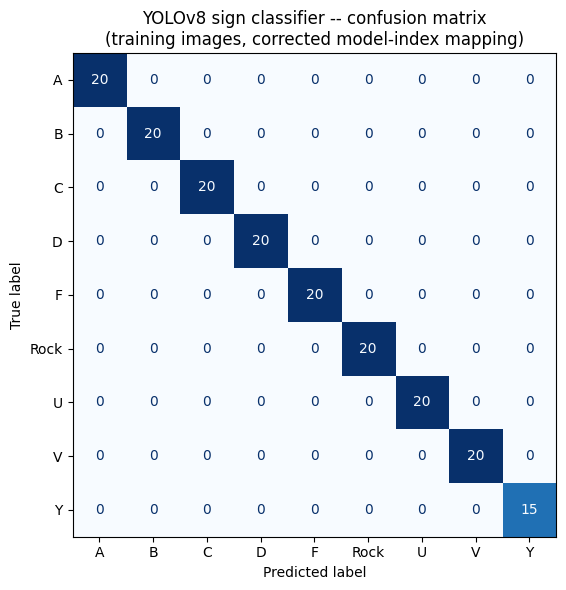

              precision    recall  f1-score   support

           A      1.000     1.000     1.000        20
           B      1.000     1.000     1.000        20
           C      1.000     1.000     1.000        20
           D      1.000     1.000     1.000        20
           F      1.000     1.000     1.000        20
        Rock      1.000     1.000     1.000        20
           U      1.000     1.000     1.000        20
           V      1.000     1.000     1.000        20
           Y      1.000     1.000     1.000        15

    accuracy                          1.000       175
   macro avg      1.000     1.000     1.000       175
weighted avg      1.000     1.000     1.000       175



In [6]:
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

DATA_DIR = Path('../../../../datos/bases/Hand_gesture/Data')
# What sign was actually filmed in each folder (collect_imgs.py convention) -- this is
# ground truth and unrelated to the model-output-index bug fixed above.
FOLDER_LABELS = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'F', 5: 'Rock', 6: 'U', 7: 'V', 8: 'Y'}
CLASS_ORDER = [FOLDER_LABELS[i] for i in range(9)]

model_eval = YOLO(model_directory)
y_true, y_pred, no_detection = [], [], []

for true_idx in range(9):
    folder = DATA_DIR / str(true_idx)
    for img_path in sorted(folder.glob('*.jpg')):
        result = model_eval.predict(str(img_path), verbose=False)[0]
        if len(result.boxes) == 0:
            no_detection.append((true_idx, img_path.name))
            continue
        best = result.boxes.conf.argmax().item()
        pred_cls = int(result.boxes.cls[best].item())
        y_true.append(FOLDER_LABELS[true_idx])
        y_pred.append(labels[pred_cls])  # `labels` = corrected MODEL-index mapping from above

print(f'Evaluated {len(y_true)}/180 images ({len(no_detection)} with no detection: {no_detection})')

cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('YOLOv8 sign classifier -- confusion matrix\n(training images, corrected model-index mapping)')
plt.tight_layout()
plt.savefig('../datos/resultados/confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, labels=CLASS_ORDER, digits=3, zero_division=0))

With the corrected model-index mapping, YOLOv8 gets every evaluated image right (175/175, the 5 without a detection are all from class `Y` -- likely a lighting/framing issue in those specific captures, not a labeling problem). Before the fix, raw accuracy was only 57.1%, entirely explained by that index mismatch on classes 5-8 -- not by the model actually confusing signs. **This also means the live demo (`implementation()` above) was showing the wrong letter on screen for Rock/U/V/Y before this fix.**

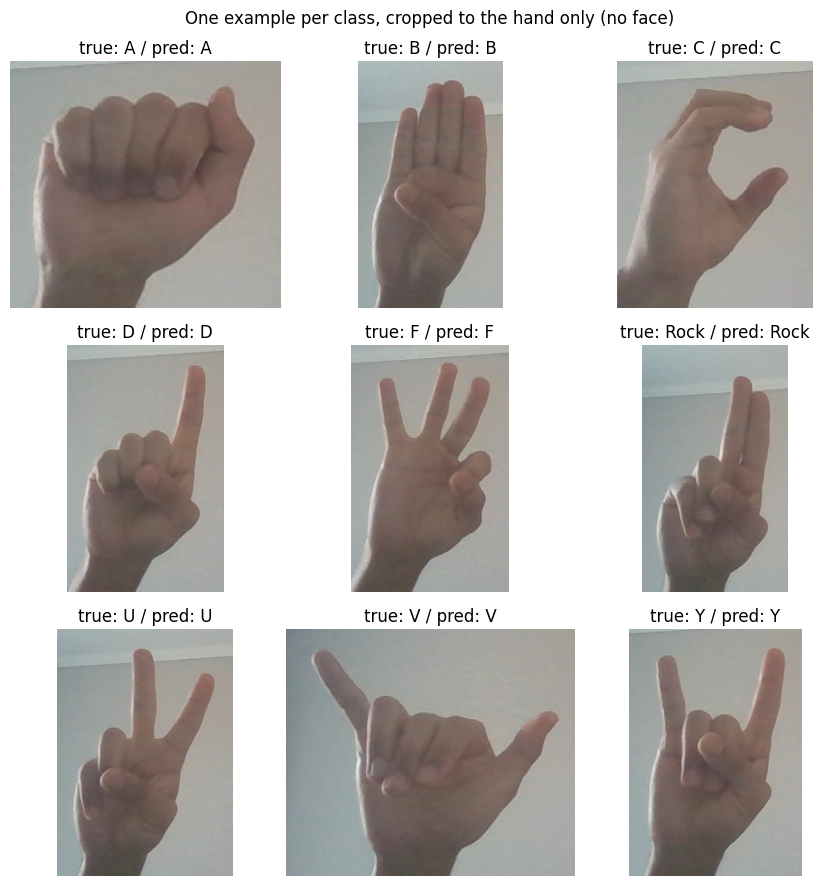

In [7]:
# A static "prediction overlaid" capture for the README, cropped tight to the hand
# bounding box only -- these webcam captures are close-up selfies with the face clearly
# visible in frame, so anything wider than the hand crop cannot leave this notebook/the
# datos/bases external folder (see "Training data" in the README). No live-demo GIF for
# the same reason this environment has no webcam.
# Also not using result.plot()'s own label text: it draws from the model's embedded
# model.names, which has the same uncorrected index mapping baked in from training --
# see the `labels` dict above for the corrected one, applied manually here instead.
import cv2

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for idx_, ax in zip(range(9), axes.flat):
    folder = DATA_DIR / str(idx_)
    img_path = sorted(folder.glob("*.jpg"))[0]
    result = model_eval.predict(str(img_path), verbose=False)[0]
    img_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    if len(result.boxes) > 0:
        best = result.boxes.conf.argmax().item()
        pred_cls = int(result.boxes.cls[best].item())
        x1, y1, x2, y2 = result.boxes.xyxy[best].tolist()
        pad = 15
        h, w, _ = img_rgb.shape
        x1c, y1c = max(0, int(x1) - pad), max(0, int(y1) - pad)
        x2c, y2c = min(w, int(x2) + pad), min(h, int(y2) + pad)
        crop = img_rgb[y1c:y2c, x1c:x2c]
        ax.imshow(crop)
        ax.set_title(f"true: {FOLDER_LABELS[idx_]} / pred: {labels[pred_cls]}")
    else:
        ax.set_title(f"true: {FOLDER_LABELS[idx_]} / no detection")
    ax.axis("off")
plt.suptitle("One example per class, cropped to the hand only (no face)")
plt.tight_layout()
plt.savefig("../datos/resultados/predictions_sample.png", dpi=150)
plt.show()

### Baseline liviano: landmarks de MediaPipe + RandomForest

En vez de un modelo de deteccion de objetos (YOLOv8, que aprende de pixeles), un baseline mucho mas simple: extraer los 21 puntos de referencia de la mano con MediaPipe Hands (rapido, sin GPU) y entrenar un `RandomForestClassifier` sobre esas coordenadas (normalizadas respecto a la muneca).

In [8]:
import mediapipe as mp
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

mp_hands_eval = mp.solutions.hands.Hands(static_image_mode=True, max_num_hands=1,
                                          min_detection_confidence=0.3)

X, y_lm, failed = [], [], []
for true_idx in range(9):
    folder = DATA_DIR / str(true_idx)
    for img_path in sorted(folder.glob('*.jpg')):
        img = cv2.imread(str(img_path))
        result = mp_hands_eval.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if not result.multi_hand_landmarks:
            failed.append((true_idx, img_path.name))
            continue
        coords = np.array([[p.x, p.y, p.z] for p in result.multi_hand_landmarks[0].landmark])
        coords_rel = (coords - coords[0]).flatten()  # relative to the wrist landmark
        X.append(coords_rel)
        y_lm.append(FOLDER_LABELS[true_idx])  # ground truth = what was filmed, not the YOLO index quirk

X = np.array(X)
print(f'Landmarks extracted for {len(y_lm)}/180 images ({len(failed)} failed: {failed})')

clf = RandomForestClassifier(n_estimators=200, random_state=42)
cv_scores = cross_val_score(clf, X, y_lm, cv=StratifiedKFold(5, shuffle=True, random_state=42))
print(f'RandomForest on MediaPipe landmarks -- 5-fold CV accuracy: '
      f'{cv_scores.mean():.3f} +/- {cv_scores.std():.3f}')
print('Per fold:', np.round(cv_scores, 3))

Landmarks extracted for 180/180 images (0 failed: [])


RandomForest on MediaPipe landmarks -- 5-fold CV accuracy: 0.983 +/- 0.022
Per fold: [          1           1       0.972       0.944           1]


**Resultado:** el baseline de landmarks llega a ~98% de accuracy con validacion cruzada de 5 folds -- una medida genuinamente fuera de muestra, a diferencia del 100% de YOLOv8 (que es sobre las mismas imagenes de entrenamiento). MediaPipe tambien detecto una mano en las 180/180 imagenes, 5 mas que YOLOv8. Practicamente empatan en exactitud, pero el baseline de landmarks es mucho mas liviano (sin GPU, sin entrenar una red de deteccion) y aca quedo evaluado de forma mas honesta -- buena razon para preferirlo si el objetivo es solo clasificar la forma de la mano ya recortada, y no localizarla en la imagen (que es lo que YOLOv8 aporta de mas).